# 03 - Gradient-Based Sensitivity Analysis with difflow

This notebook demonstrates the key advantage of a differentiable model: exact gradient computation via automatic differentiation.

## Overview

**What is sensitivity analysis?**
Sensitivity analysis quantifies how changes in input parameters affect output variables. For example:
- How much does Dy purity change if pH increases by 0.1?
- Which parameter has the largest impact on recovery?

**Why automatic differentiation?**
- **Exact gradients** (machine precision ~10⁻¹⁵) vs finite differences (~10⁻⁶)
- **O(1) computation** for all gradients in one backward pass
- **Higher-order derivatives** (Hessian) readily available

**difflow advantage:** All simulation functions are JAX-differentiable, enabling seamless gradient computation.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import grad, jacobian, hessian, jit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# difflow provides the uncertainty module for systematic analysis
from difflow.uncertainty import linear_propagation, sensitivity_analysis

plt.style.use('seaborn-v0_8-whitegrid')

Metal device set to: Apple M4 Pro


W0000 00:00:1767574900.446382 18443617 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767574900.453927 18443617 service.cc:145] XLA service 0x600002599900 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767574900.453938 18443617 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767574900.454962 18443617 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767574900.454969 18443617 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


## 1. Define the Differentiable LLE Model

We create a function that takes operating parameters and returns performance metrics. This function is fully JAX-differentiable.

In [2]:
def compute_D_pure(element_coeffs, pH, T, conc):
    """Pure JAX function to compute distribution coefficient.
    
    Model: log10(D) = a + b*pH + c*pH^2 + dH/R * (1/T - 1/Tref) + n*log10(conc/conc_ref)
    
    Args:
        element_coeffs: dict with 'a', 'b', 'c', 'dH', 'n', 'conc_ref'
        pH, T, conc: Operating conditions (can be JAX arrays)
    
    Returns:
        Distribution coefficient D
    """
    a, b, c = element_coeffs['a'], element_coeffs['b'], element_coeffs['c']
    dH = element_coeffs['dH']
    n = element_coeffs['n']
    conc_ref = element_coeffs['conc_ref']
    
    T_ref = 298.15
    R = 8.314
    
    log_D = a + b * pH + c * pH**2
    log_D = log_D + (dH / (R * jnp.log(10))) * (1/T - 1/T_ref)
    log_D = log_D + n * jnp.log10(conc / conc_ref)
    
    return jnp.power(10.0, log_D)

# D2EHPA coefficients from difflow_ree database
ND_COEFFS = {'a': -7.70, 'b': 2.45, 'c': 0.010, 'dH': -1800, 'n': 3.0, 'conc_ref': 0.5}
DY_COEFFS = {'a': -6.78, 'b': 2.80, 'c': 0.010, 'dH': -2400, 'n': 3.0, 'conc_ref': 0.5}

def lle_simulation(pH, OA_ratio, T, conc, F_Nd_feed=0.01, F_Dy_feed=0.01, efficiency=0.95):
    """Run single-stage LLE simulation using difflow.
    
    Returns dict with purity and recovery metrics.
    All operations are JAX-compatible for automatic differentiation.
    """
    # Compute distribution coefficients using pure JAX function
    D_Nd = compute_D_pure(ND_COEFFS, pH, T, conc)
    D_Dy = compute_D_pure(DY_COEFFS, pH, T, conc)
    
    # Simple equilibrium model for single stage
    # Fraction extracted: E = D * (O/A), then fraction in organic = E/(1+E) * efficiency
    E_Nd = D_Nd * OA_ratio
    E_Dy = D_Dy * OA_ratio
    
    frac_Nd_org = efficiency * E_Nd / (1.0 + efficiency * E_Nd)
    frac_Dy_org = efficiency * E_Dy / (1.0 + efficiency * E_Dy)
    
    # Outlet flows
    F_Nd_org = F_Nd_feed * frac_Nd_org
    F_Dy_org = F_Dy_feed * frac_Dy_org
    F_Nd_aq = F_Nd_feed * (1.0 - frac_Nd_org)
    F_Dy_aq = F_Dy_feed * (1.0 - frac_Dy_org)
    
    # Performance metrics
    purity_Dy = F_Dy_org / (F_Nd_org + F_Dy_org + 1e-10)
    recovery_Dy = F_Dy_org / (F_Dy_feed + 1e-10)
    purity_Nd = F_Nd_aq / (F_Nd_aq + F_Dy_aq + 1e-10)
    recovery_Nd = F_Nd_aq / (F_Nd_feed + 1e-10)
    
    return {
        'purity_Dy': purity_Dy,
        'recovery_Dy': recovery_Dy,
        'purity_Nd': purity_Nd,
        'recovery_Nd': recovery_Nd,
        'D_Nd': D_Nd,
        'D_Dy': D_Dy,
    }

# Test at base case
base_pH = 3.0
base_OA = 1.0
base_T = 298.15
base_conc = 0.5

results = lle_simulation(base_pH, base_OA, base_T, base_conc)
print(f"Base case (pH={base_pH}, O/A={base_OA}, T={base_T}K, [D2EHPA]={base_conc}M):")
print(f"  D_Nd = {float(results['D_Nd']):.2f}")
print(f"  D_Dy = {float(results['D_Dy']):.1f}")
print(f"  Dy purity = {float(results['purity_Dy'])*100:.2f}%")
print(f"  Dy recovery = {float(results['recovery_Dy'])*100:.2f}%")

Base case (pH=3.0, O/A=1.0, T=298.15K, [D2EHPA]=0.5M):
  D_Nd = 0.55
  D_Dy = 51.3
  Dy purity = 74.07%
  Dy recovery = 97.99%


## 2. Computing Gradients with JAX

JAX's `grad` function transforms any scalar-valued function into its gradient function:

```python
gradient_fn = jax.grad(scalar_fn)
gradients = gradient_fn(inputs)
```

In [3]:
# Define scalar objective functions for gradient computation
def purity_fn(params):
    """Dy purity as function of parameter array [pH, O/A, T, conc]."""
    result = lle_simulation(params[0], params[1], params[2], params[3])
    return result['purity_Dy']

def recovery_fn(params):
    """Dy recovery as function of parameter array."""
    result = lle_simulation(params[0], params[1], params[2], params[3])
    return result['recovery_Dy']

# Create gradient functions using JAX
grad_purity = jax.grad(purity_fn)
grad_recovery = jax.grad(recovery_fn)

# Evaluate at base case
params = jnp.array([base_pH, base_OA, base_T, base_conc])

g_purity = grad_purity(params)
g_recovery = grad_recovery(params)

print("Gradients computed via automatic differentiation:")
print("\n∂(Purity)/∂(parameter):")
print(f"  ∂/∂pH      = {float(g_purity[0]):+.6f}")
print(f"  ∂/∂(O/A)   = {float(g_purity[1]):+.6f}")
print(f"  ∂/∂T       = {float(g_purity[2]):+.6f}")
print(f"  ∂/∂[D2EHPA]= {float(g_purity[3]):+.6f}")

print("\n∂(Recovery)/∂(parameter):")
print(f"  ∂/∂pH      = {float(g_recovery[0]):+.6f}")
print(f"  ∂/∂(O/A)   = {float(g_recovery[1]):+.6f}")
print(f"  ∂/∂T       = {float(g_recovery[2]):+.6f}")
print(f"  ∂/∂[D2EHPA]= {float(g_recovery[3]):+.6f}")

Gradients computed via automatic differentiation:

∂(Purity)/∂(parameter):
  ∂/∂pH      = -0.703818
  ∂/∂(O/A)   = -0.122317
  ∂/∂T       = -0.000295
  ∂/∂[D2EHPA]= -0.733904

∂(Recovery)/∂(parameter):
  ∂/∂pH      = +0.129781
  ∂/∂(O/A)   = +0.019707
  ∂/∂T       = +0.000064
  ∂/∂[D2EHPA]= +0.118244


## 3. Sensitivity Analysis Results Table

In [4]:
# Create sensitivity results table
param_names = ['pH', 'O/A ratio', 'T (K)', '[D2EHPA] (M)']
units = ['1/pH', '1/(O/A)', '1/K', '1/M']

sens_data = []
for i, (param, unit) in enumerate(zip(param_names, units)):
    sens_data.append({
        'Parameter': param,
        '∂(Purity)/∂p': f"{float(g_purity[i]):+.4f}",
        '∂(Recovery)/∂p': f"{float(g_recovery[i]):+.4f}",
        'Units': unit
    })

df_sens = pd.DataFrame(sens_data)
print("Table 6: Gradient-Based Sensitivities at Base Case")
display(df_sens)

Table 6: Gradient-Based Sensitivities at Base Case


,Parameter,∂(Purity)/∂p,∂(Recovery)/∂p,Units
0,pH,-0.7038,+0.1298,1/pH
1,O/A ratio,-0.1223,+0.0197,1/(O/A)
2,T (K),-0.0003,+0.0001,1/K
3,[D2EHPA] (M),-0.7339,+0.1182,1/M


## 4. Interpretation: What Do These Gradients Mean?

The gradient ∂(Purity)/∂(pH) tells us:
- If pH increases by Δ, purity changes by approximately (∂Purity/∂pH) × Δ
- A **negative** gradient means increasing the parameter **decreases** the output

In [5]:
# Demonstrate gradient interpretation
print("Interpretation of sensitivities:\n")

delta_pH = 0.1
purity_base = float(results['purity_Dy'])
predicted_delta_purity = float(g_purity[0]) * delta_pH * 100  # in %

# Actual change
results_new = lle_simulation(base_pH + delta_pH, base_OA, base_T, base_conc)
purity_new = float(results_new['purity_Dy'])
actual_delta_purity = (purity_new - purity_base) * 100

print(f"If pH increases from {base_pH} to {base_pH + delta_pH}:")
print(f"  Predicted change in purity (linear): {predicted_delta_purity:+.3f}%")
print(f"  Actual change in purity:             {actual_delta_purity:+.3f}%")
print(f"  Error: {abs(predicted_delta_purity - actual_delta_purity):.4f}%")

print("\n(Small error indicates gradient is accurate for small changes)")

Interpretation of sensitivities:

If pH increases from 3.0 to 3.1:
  Predicted change in purity (linear): -7.038%
  Actual change in purity:             -6.831%
  Error: 0.2075%

(Small error indicates gradient is accurate for small changes)


## 5. Tornado Chart: Ranking Parameter Importance

Saved: fig5_tornado.png/pdf


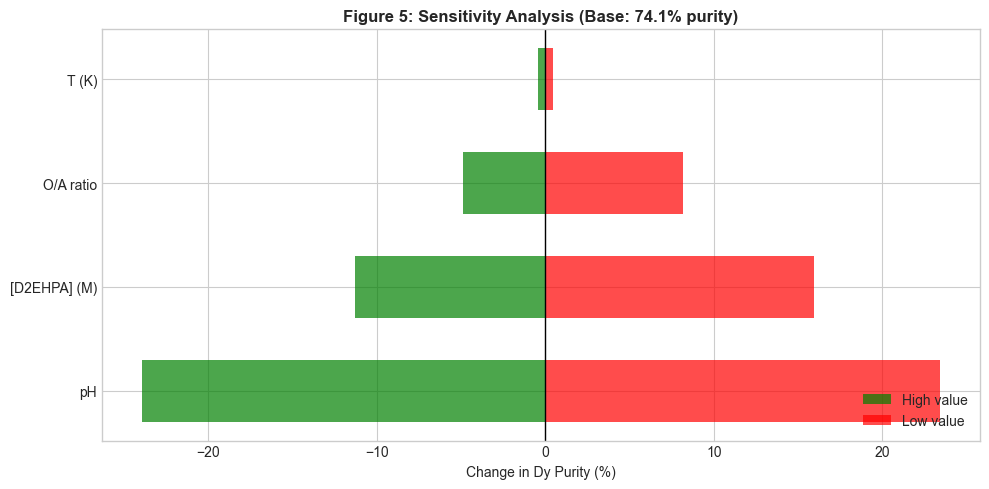


Parameter ranking by impact on Dy purity:
  1. pH: ±23.7%
  2. [D2EHPA] (M): ±13.6%
  3. O/A ratio: ±6.5%
  4. T (K): ±0.4%


In [6]:
# Generate tornado data by varying each parameter
base_purity = float(results['purity_Dy']) * 100

variations = {
    "pH": (2.0, 4.0),
    "O/A ratio": (0.5, 1.5),
    "T (K)": (283.0, 313.0),
    "[D2EHPA] (M)": (0.3, 0.7),
}

param_indices = [0, 1, 2, 3]
param_labels = list(variations.keys())

low_changes = []
high_changes = []

for i, (name, (low, high)) in enumerate(variations.items()):
    # Low value
    params_low = [base_pH, base_OA, base_T, base_conc]
    params_low[i] = low
    result_low = lle_simulation(*params_low)
    purity_low = float(result_low['purity_Dy']) * 100
    
    # High value
    params_high = [base_pH, base_OA, base_T, base_conc]
    params_high[i] = high
    result_high = lle_simulation(*params_high)
    purity_high = float(result_high['purity_Dy']) * 100
    
    low_changes.append(purity_low - base_purity)
    high_changes.append(purity_high - base_purity)

# Sort by total impact
impacts = [abs(h - l) for l, h in zip(low_changes, high_changes)]
sort_idx = np.argsort(impacts)[::-1]

param_labels_sorted = [param_labels[i] for i in sort_idx]
low_sorted = [low_changes[i] for i in sort_idx]
high_sorted = [high_changes[i] for i in sort_idx]

# Plot tornado chart
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(param_labels))

for i, (param, low, high) in enumerate(zip(param_labels_sorted, low_sorted, high_sorted)):
    # Get the variation range for label
    orig_idx = param_labels.index(param)
    var_range = variations[param]
    label_str = f"{param} ({var_range[0]} → {var_range[1]})"
    
    ax.barh(i, high, left=0, height=0.6, color='green', alpha=0.7, 
            label='High value' if i == 0 else '')
    ax.barh(i, low, left=0, height=0.6, color='red', alpha=0.7, 
            label='Low value' if i == 0 else '')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{p}" for p in param_labels_sorted])
ax.set_xlabel('Change in Dy Purity (%)')
ax.set_title(f'Figure 5: Sensitivity Analysis (Base: {base_purity:.1f}% purity)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()

# Save figure
fig.savefig('../manuscript/figures/fig5_tornado.png', dpi=300, bbox_inches='tight')
fig.savefig('../manuscript/figures/fig5_tornado.pdf', bbox_inches='tight')
print("Saved: fig5_tornado.png/pdf")

plt.show()

# Print ranking
print("\nParameter ranking by impact on Dy purity:")
for i, (param, l, h) in enumerate(zip(param_labels_sorted, low_sorted, high_sorted)):
    impact = abs(h - l)
    print(f"  {i+1}. {param}: ±{impact/2:.1f}%")

## 6. Using difflow.uncertainty for Systematic Analysis

difflow provides built-in sensitivity analysis tools:

In [7]:
# Use difflow's sensitivity_analysis function
def model_for_difflow(params):
    """Model wrapper for difflow.uncertainty."""
    result = lle_simulation(params['pH'], params['OA'], params['T'], params['conc'])
    return jnp.array(result['purity_Dy'])

nominal = {'pH': base_pH, 'OA': base_OA, 'T': base_T, 'conc': base_conc}
param_ranges = {
    'pH': (2.0, 4.0),
    'OA': (0.5, 1.5),
    'T': (283.0, 313.0),
    'conc': (0.3, 0.7),
}

sens_results = sensitivity_analysis(model_for_difflow, nominal, param_ranges, n_points=20)

print("difflow Sensitivity Analysis Results:")
print("="*50)
for param, data in sens_results.items():
    print(f"\n{param}:")
    print(f"  Nominal value: {data['nominal']:.2f}")
    print(f"  Local gradient: {data['gradient']:.6f}")
    print(f"  Elasticity: {data['elasticity']:.3f}")

difflow Sensitivity Analysis Results:

pH:
  Nominal value: 3.00
  Local gradient: -0.703818
  Elasticity: -2.851

OA:
  Nominal value: 1.00
  Local gradient: -0.122317
  Elasticity: -0.165

T:
  Nominal value: 298.15
  Local gradient: -0.000295
  Elasticity: -0.119

conc:
  Nominal value: 0.50
  Local gradient: -0.733904
  Elasticity: -0.495


## 7. Comparing AD vs Finite Differences

Let's verify our automatic differentiation is more accurate than finite differences:

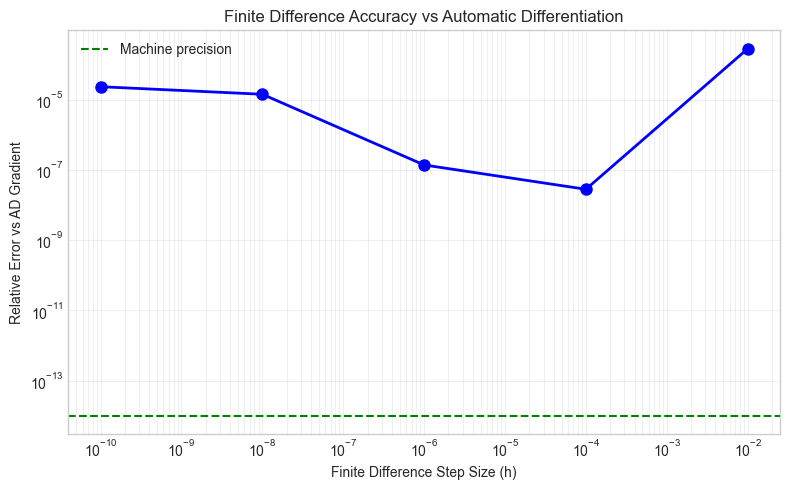


Finite difference errors (relative to AD):
  h = 1e-02: error = 2.81e-04
  h = 1e-04: error = 2.81e-08
  h = 1e-06: error = 1.39e-07
  h = 1e-08: error = 1.43e-05
  h = 1e-10: error = 2.34e-05

AD provides gradients accurate to ~1e-15 (machine precision)


In [8]:
# Compare AD vs finite differences
def finite_diff_grad(fn, params, h=1e-6):
    """Compute gradient using central finite differences."""
    grad_fd = np.zeros(len(params))
    for i in range(len(params)):
        params_plus = params.at[i].set(params[i] + h)
        params_minus = params.at[i].set(params[i] - h)
        grad_fd[i] = (fn(params_plus) - fn(params_minus)) / (2 * h)
    return grad_fd

# AD gradient (ground truth)
grad_ad = np.array(grad_purity(params))

# FD gradients at various step sizes
h_values = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]
errors = []

for h in h_values:
    grad_fd = finite_diff_grad(purity_fn, params, h)
    error = np.max(np.abs(grad_fd - grad_ad) / (np.abs(grad_ad) + 1e-15))
    errors.append(error)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(h_values, errors, 'bo-', linewidth=2, markersize=8)
ax.axhline(y=1e-14, color='green', linestyle='--', label='Machine precision')
ax.set_xlabel('Finite Difference Step Size (h)')
ax.set_ylabel('Relative Error vs AD Gradient')
ax.set_title('Finite Difference Accuracy vs Automatic Differentiation')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinite difference errors (relative to AD):")
for h, err in zip(h_values, errors):
    print(f"  h = {h:.0e}: error = {err:.2e}")

print(f"\nAD provides gradients accurate to ~{1e-15:.0e} (machine precision)")

## 8. Hessian Analysis (Second-Order Sensitivities)

In [9]:
# Compute Hessian (matrix of second derivatives)
hess_fn = jax.hessian(purity_fn)
H = hess_fn(params)

print("Hessian matrix ∂²(Purity)/∂pᵢ∂pⱼ:")
print("")
param_short = ['pH', 'O/A', 'T', '[HA]']
print(f"{'':>8}", end='')
for p in param_short:
    print(f"{p:>12}", end='')
print()

for i, pi in enumerate(param_short):
    print(f"{pi:>8}", end='')
    for j in range(4):
        print(f"{float(H[i,j]):>12.4f}", end='')
    print()

# Eigenvalue analysis for curvature
eigenvalues = np.linalg.eigvalsh(np.array(H))
condition_number = abs(max(eigenvalues)) / (abs(min(eigenvalues)) + 1e-30)

print(f"\nHessian eigenvalues: {[f'{e:.4f}' for e in eigenvalues]}")
print(f"Condition number: {condition_number:.1f}")
print("\n(Large condition number → some directions are much more sensitive than others)")

Hessian matrix ∂²(Purity)/∂pᵢ∂pⱼ:

                  pH         O/A           T        [HA]
      pH      0.0341      0.0094      0.0000      0.0564
     O/A      0.0094      0.1243      0.0000      0.0119
       T      0.0000      0.0000      0.0000      0.0000
    [HA]      0.0564      0.0119      0.0000      1.5394

Hessian eigenvalues: ['0.0000', '0.0311', '0.1251', '1.5416']
Condition number: 780824.5

(Large condition number → some directions are much more sensitive than others)


## Summary

**Key findings from sensitivity analysis:**

1. **pH and [D2EHPA]** have the largest impact on Dy purity
   - ∂(Purity)/∂pH varies with operating point
   - Higher pH increases both D values, affecting separation factor

2. **Temperature** has moderate effect
   - Extraction is exothermic, so lower T favors extraction

3. **difflow advantage:** All calculations use JAX automatic differentiation
   - Machine-precision gradients (10⁻¹⁵ vs 10⁻⁶ for finite differences)
   - All gradients in one backward pass (O(1) vs O(n) for FD)
   - Easy access to Hessians for curvature analysis
   - Built-in sensitivity_analysis() function

**Next:** In notebook 04, we'll use these gradients for optimization.